In [89]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


from sklearn.metrics import mean_squared_error
from torchvision import datasets, transforms
from pathlib import Path

import pandas as pd
import numpy as np
from joblib import dump
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    precision_recall_fscore_support,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

torch.manual_seed(42)


In [90]:
df = pd.read_parquet("data_clean.parquet")
# Nur vorhandene float-Features verwenden
X = df.select_dtypes(include=['float32']).copy()
# Target zuverlässig in bool konvertieren
y = df['target'].astype(str).str.strip().str.lower() == 'true'

# 70/15/15 split: zuerst 70/30, dann 50/50 auf das 30%-Teil
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print('Sizes: train', len(X_train), 'val', len(X_val), 'test', len(X_test))

scalers = {
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'minmax': MinMaxScaler()
}

# Fit Scaler nur auf normale Samples des Trainingssets, transformiere train/val/test getrennt
X_s_dict = {}
for name, sc in scalers.items():
    X_train_norm = X_train[~y_train].values
    sc.fit(X_train_norm)

    X_train_norm_s = sc.transform(X_train_norm)          # nur normale Trainingsproben für Autoencoder-Training
    X_val_s = sc.transform(X_val.values)                 # validierungsset (gesamtes val)
    X_test_s = sc.transform(X_test.values)               # hold-out test

    dump(sc, f"scaler_{name}.joblib")
    X_s_dict[name] = {
        'train_norm': X_train_norm_s,
        'val': X_val_s,
        'test': X_test_s,
        'y_val': y_val.values,
        'y_test': y_test.values
    }
    print(f"Scaler {name}: fitted on {X_train_norm.shape[0]} normal train samples")


Sizes: train 140000 val 30000 test 30000
Scaler standard: fitted on 125931 normal train samples
Scaler robust: fitted on 125931 normal train samples
Scaler minmax: fitted on 125931 normal train samples


In [156]:
# Wähle Scaler
scaler_name = "minmax"  # "standard" | "robust" | "minmax"

parts = X_s_dict[scaler_name]


# ============================================================
# Training
# Nur target = 0
# ============================================================

X_train_tensor = torch.tensor(
    parts["train_norm"],
    dtype=torch.float32
)

train_ds = TensorDataset(
    X_train_tensor,
    X_train_tensor
)

train_loader = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True
)


# ============================================================
# Validation
# X + echte Labels
# ============================================================

X_val_tensor = torch.tensor(
    parts["val"],
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    parts["y_val"].astype(int),
    dtype=torch.long
)

val_ds = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

val_loader = DataLoader(
    val_ds,
    batch_size=256,
    shuffle=False
)


# ============================================================
# Test
# X + echte Labels
# ============================================================

X_test_tensor = torch.tensor(
    parts["test"],
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    parts["y_test"].astype(int),
    dtype=torch.long
)

test_ds = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False
)


# NumPy Labels für spätere Evaluation
y_val = parts["y_val"].astype(int)
y_test = parts["y_test"].astype(int)


print("Scaler:", scaler_name)
print("train_norm shape:", parts["train_norm"].shape)
print("val shape:", parts["val"].shape)
print("test shape:", parts["test"].shape)

print()
print("Validation target 0:", np.sum(y_val == 0))
print("Validation target 1:", np.sum(y_val == 1))
print("Test target 0:", np.sum(y_test == 0))
print("Test target 1:", np.sum(y_test == 1))

# Gaussian noise, defined by its standarddeviation
def add_noise(x ,stdev_noise=0.5):
    x_noisy = x + 0.5 * torch.randn_like(x) * stdev_noise
    return x_noisy

Scaler: minmax
train_norm shape: (125931, 200)
val shape: (30000, 200)
test shape: (30000, 200)

Validation target 0: 26985
Validation target 1: 3015
Test target 0: 26986
Test target 1: 3014


In [ ]:
class MyAutoencoder(nn.Module):
    def __init__(self, input_dim, lat_space_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.4),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.4),
            nn.Linear(64, lat_space_dim)  # latent space
        )

        self.decoder = nn.Sequential(
            nn.Linear(lat_space_dim, 64),
            nn.LeakyReLU(0.4),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.4),
            nn.Linear(128, input_dim)  # roher Regressionsoutput

        )

    def forward(self, x):
        z = self.encoder(x)  # encode input in z
        x_hat = self.decoder(z)  # reconstruct from z
        return x_hat


In [163]:
input_dim = X_train_tensor.shape[1]
lat_space_dim = 32
n_epochs = 100


model = MyAutoencoder(
    input_dim=input_dim,
    lat_space_dim=lat_space_dim
)

loss_fn = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.003
)


train_losses = []

val_losses = []
val_losses_target_0 = []
val_losses_target_1 = []


train_size = len(train_loader.dataset)


for epoch in range(1, n_epochs + 1):

    # ========================================================
    # Training
    # ========================================================

    model.train()

    running_train_loss = 0.0

    for x_train_batch, _ in train_loader:

        x_noisy_batch = add_noise(x_train_batch, stdev_noise=1.0)

        #x_hat = model(x_train_batch)
        x_hat = model(x_noisy_batch)

        train_loss = loss_fn(
            x_hat,
            x_train_batch
        )

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        batch_size = x_train_batch.size(0)

        running_train_loss += (
            train_loss.item() * batch_size
        )


    epoch_train_loss = (
        running_train_loss / train_size
    )

    train_losses.append(
        epoch_train_loss
    )


    # ========================================================
    # Validation
    # ========================================================

    model.eval()

    val_errors_all = []
    val_errors_target_0 = []
    val_errors_target_1 = []


    with torch.no_grad():

        for x_val_batch, y_val_batch in val_loader:

            x_hat_val = model(x_val_batch)

            # Rekonstruktionsfehler pro Sample
            reconstruction_error = (
                (x_hat_val - x_val_batch) ** 2
            ).mean(dim=1)


            # Alle Samples
            val_errors_all.extend(
                reconstruction_error.cpu().numpy()
            )


            # Nur target = 0
            mask_0 = (y_val_batch == 0)

            val_errors_target_0.extend(
                reconstruction_error[mask_0]
                .cpu()
                .numpy()
            )


            # Nur target = 1
            mask_1 = (y_val_batch == 1)

            val_errors_target_1.extend(
                reconstruction_error[mask_1]
                .cpu()
                .numpy()
            )


    # ========================================================
    # Mean Reconstruction Error
    # ========================================================

    epoch_val_loss = np.mean(
        val_errors_all
    )

    epoch_val_loss_0 = np.mean(
        val_errors_target_0
    )

    epoch_val_loss_1 = np.mean(
        val_errors_target_1
    )


    val_losses.append(
        epoch_val_loss
    )

    val_losses_target_0.append(
        epoch_val_loss_0
    )

    val_losses_target_1.append(
        epoch_val_loss_1
    )

    print(
        f"Epoch {epoch:3d}: "
        f"train={epoch_train_loss:.5f} | "
        f"val all={epoch_val_loss:.5f} | "
        f"val target 0={epoch_val_loss_0:.5f} | "
        f"val target 1={epoch_val_loss_1:.5f}"
    )

Epoch   1: train=0.69166 | val all=0.27962 | val target 0=0.27949 | val target 1=0.28076
Epoch   2: train=0.69155 | val all=0.28116 | val target 0=0.28105 | val target 1=0.28214
Epoch   3: train=0.69152 | val all=0.28131 | val target 0=0.28120 | val target 1=0.28222
Epoch   4: train=0.69150 | val all=0.28211 | val target 0=0.28204 | val target 1=0.28281
Epoch   5: train=0.69148 | val all=0.28170 | val target 0=0.28163 | val target 1=0.28235
Epoch   6: train=0.69146 | val all=0.27959 | val target 0=0.27952 | val target 1=0.28024
Epoch   7: train=0.69145 | val all=0.27975 | val target 0=0.27966 | val target 1=0.28052
Epoch   8: train=0.69144 | val all=0.27922 | val target 0=0.27914 | val target 1=0.27995
Epoch   9: train=0.69144 | val all=0.27795 | val target 0=0.27788 | val target 1=0.27858
Epoch  10: train=0.69144 | val all=0.28119 | val target 0=0.28111 | val target 1=0.28188
Epoch  11: train=0.69143 | val all=0.27884 | val target 0=0.27877 | val target 1=0.27952
Epoch  12: train=0.69

KeyboardInterrupt: 

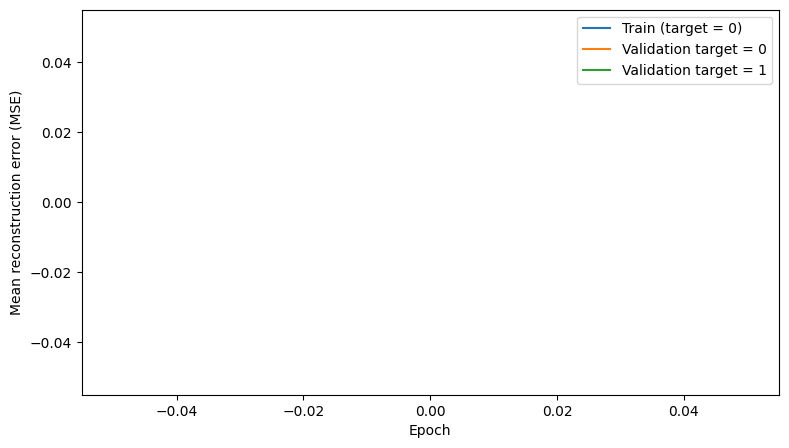

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    train_losses,
    label="Train (target = 0)"
)

plt.plot(
    val_losses_target_0,
    label="Validation target = 0"
)

plt.plot(
    val_losses_target_1,
    label="Validation target = 1"
)

plt.xlabel("Epoch")
plt.ylabel("Mean reconstruction error (MSE)")
plt.legend()

plt.show()

Validation reconstruction error:
target 0: mean=0.023634, median=0.023578
target 1: mean=0.025759, median=0.025724

Test reconstruction error:
target 0: mean=0.023627, median=0.023578
target 1: mean=0.025766, median=0.025715

Threshold (F1-optimal auf Val): 2.606111e-02 (Val-F1: 0.3508)

Test:
AUC:       0.7588
Precision: 0.2839
Recall:    0.4409
F1:        0.3454


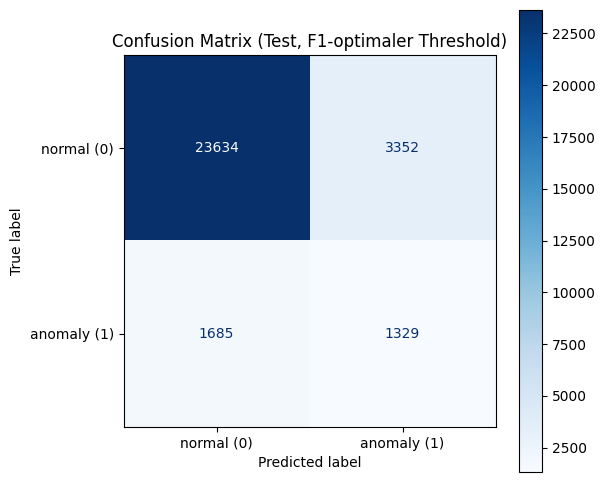

True Negatives:  23634
False Positives: 3352
False Negatives: 1685
True Positives:  1329


In [ ]:
model.eval()

recon_val = []
recon_test = []

labels_val = []
labels_test = []


with torch.no_grad():

    # ========================================================
    # Validation
    # ========================================================

    for xb, yb in val_loader:

        x_hat = model(xb)

        batch_error = (
            (x_hat - xb) ** 2
        ).mean(dim=1)

        recon_val.extend(
            batch_error.cpu().numpy()
        )

        labels_val.extend(
            yb.cpu().numpy()
        )


    # ========================================================
    # Test
    # ========================================================

    for xb, yb in test_loader:

        x_hat = model(xb)

        batch_error = (
            (x_hat - xb) ** 2
        ).mean(dim=1)

        recon_test.extend(
            batch_error.cpu().numpy()
        )

        labels_test.extend(
            yb.cpu().numpy()
        )


recon_val = np.array(recon_val)
recon_test = np.array(recon_test)

y_val_arr = np.array(labels_val)
y_test_arr = np.array(labels_test)


# ============================================================
# Reconstruction Error nach Klasse
# ============================================================

val_error_target_0 = recon_val[
    y_val_arr == 0
]

val_error_target_1 = recon_val[
    y_val_arr == 1
]


test_error_target_0 = recon_test[
    y_test_arr == 0
]

test_error_target_1 = recon_test[
    y_test_arr == 1
]


print("Validation reconstruction error:")
print(
    f"target 0: mean={val_error_target_0.mean():.6f}, "
    f"median={np.median(val_error_target_0):.6f}"
)

print(
    f"target 1: mean={val_error_target_1.mean():.6f}, "
    f"median={np.median(val_error_target_1):.6f}"
)


print("\nTest reconstruction error:")
print(
    f"target 0: mean={test_error_target_0.mean():.6f}, "
    f"median={np.median(test_error_target_0):.6f}"
)

print(
    f"target 1: mean={test_error_target_1.mean():.6f}, "
    f"median={np.median(test_error_target_1):.6f}"
)


# ============================================================
# Threshold auf Validation Set bestimmen
# ============================================================

prec_curve, rec_curve, thresh_curve = (
    precision_recall_curve(
        y_val_arr,
        recon_val
    )
)

f1_curve = (
    2 * prec_curve * rec_curve
    / (prec_curve + rec_curve + 1e-12)
)

best_idx = np.argmax(
    f1_curve[:-1]
)

threshold = thresh_curve[
    best_idx
]


print(
    f"\nThreshold (F1-optimal auf Val): "
    f"{threshold:.6e} "
    f"(Val-F1: {f1_curve[best_idx]:.4f})"
)


# ============================================================
# Test Evaluation
# ============================================================

y_pred = (
    recon_test > threshold
).astype(int)

auc = roc_auc_score(
    y_test_arr,
    recon_test
)

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        y_test_arr,
        y_pred,
        average="binary",
        zero_division=0
    )
)


print(
    f"\nTest:"
    f"\nAUC:       {auc:.4f}"
    f"\nPrecision: {precision:.4f}"
    f"\nRecall:    {recall:.4f}"
    f"\nF1:        {f1:.4f}"
)

cm = confusion_matrix(
    y_test_arr,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["normal (0)", "anomaly (1)"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix (Test, F1-optimaler Threshold)")
plt.show()


# ============================================================
# Werte einzeln ausgeben
# ============================================================

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")



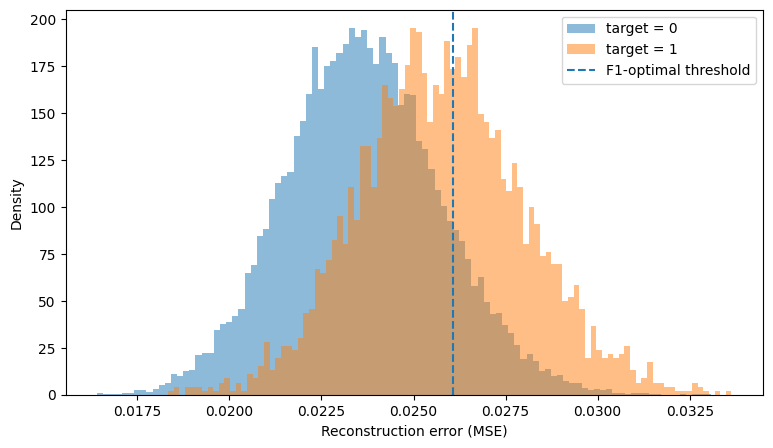

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    test_error_target_0,
    bins=100,
    density=True,
    alpha=0.5,
    label="target = 0"
)

plt.hist(
    test_error_target_1,
    bins=100,
    density=True,
    alpha=0.5,
    label="target = 1"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="F1-optimal threshold"
)

plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Density")
plt.legend()

plt.show()